In [88]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
df = pd.read_csv("./data_avance.csv")

In [3]:
df.isnull().sum()

Unnamed: 0                        0
id                                0
name                              0
university                        0
emp_rate                          0
career                            0
total_students                    0
new_graduates_number              0
public_cost                       0
private_cost                      0
public_quality_rating             0
private_quality_rating            0
occupation_rate                   0
unemployment_rate                 0
informality_rate                  0
quality_employment_probability    0
average_salary                    0
career_rank                       0
women_salary                      0
men_salary                        0
under_30_salary                   0
over_30_salary                    0
formal_salary                     0
informal_salary                   0
postgrad_percentage               0
postgrad_salary                   0
salary_increase                   0
dtype: int64

In [4]:
df.dtypes

Unnamed: 0                          int64
id                                  int64
name                               object
university                          int64
emp_rate                          float64
career                             object
total_students                     object
new_graduates_number              float64
public_cost                        object
private_cost                       object
public_quality_rating              object
private_quality_rating             object
occupation_rate                    object
unemployment_rate                  object
informality_rate                   object
quality_employment_probability     object
average_salary                     object
career_rank                        object
women_salary                       object
men_salary                         object
under_30_salary                    object
over_30_salary                     object
formal_salary                      object
informal_salary                   

In [5]:
df

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337.269,10.559,$47.375,$248.283,...,7°,$24.108,$25.518,$21.204,$26.826,$27.119,$18.928,3.9%,$41.396,"191,62%"
1,1,0,Ingeniería Civil,2,82.8,construcción_e_ingeniería_civil,337.269,10.559,$47.375,$248.283,...,7°,$24.108,$25.518,$21.204,$26.826,$27.119,$18.928,3.9%,$41.396,"191,62%"
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109.896,990.000,$42.437,$90.757,...,5°,$23.723,$26.821,$17.118,$28.654,$27.745,$17.327,6.9%,$43.574,"206,11%"
3,3,1,Ingeniería en Tecnologías Computacionales,2,85.3,ciencias_computacionales,109.896,990.000,$42.437,$90.757,...,5°,$23.723,$26.821,$17.118,$28.654,$27.745,$17.327,6.9%,$43.574,"206,11%"
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601.331,40.232,$49.736,$393.684,...,15°,$19.942,$24.854,$20.188,$25.369,$25.109,$14.568,3.2%,$43.391,"214,62%"
5,5,2,Ingeniería Industrial y de Sistemas,2,81.0,ingeniería_industrial,601.331,40.232,$49.736,$393.684,...,15°,$19.942,$24.854,$20.188,$25.369,$25.109,$14.568,3.2%,$43.391,"214,62%"
6,6,3,Ingeniería Eléctrica,1,74.5,electrónica_automatización_y_aplicaciones_de_l...,408.206,24.702,$54.886,$496.800,...,4°,$21.431,$26.108,$21.596,$28.051,$27.429,$15.484,1.9%,$41.086,"185,06%"
7,7,3,Ingeniería en Electrónica y Semiconductores,2,77.8,electrónica_automatización_y_aplicaciones_de_l...,408.206,24.702,$54.886,$496.800,...,4°,$21.431,$26.108,$21.596,$28.051,$27.429,$15.484,1.9%,$41.086,"185,06%"
8,8,4,Ingeniería Mecánica,1,80.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205.424,11.478,$51.344,$1.2M,...,11°,$29.237,$23.165,$22.696,$24.811,$25.981,$14.836,1.2%,$42.794,"206,03%"
9,9,4,Ingeniería Mecánica,2,81.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205.424,11.478,$51.344,$1.2M,...,11°,$29.237,$23.165,$22.696,$24.811,$25.981,$14.836,1.2%,$42.794,"206,03%"


In [6]:
def fix_number(x):
    x = str(x)
    if "-" == x:
        return 0
    if "M" in x:
        print("Millón")
        x = float(x.replace('M',''))
        x = x * 1000000
        return int(x)
    if x.endswith(".0"):
        parts = x.split('.')
        print(parts[0], flush=True)
        return int(parts[0])
    else:
        return int(float(x.replace('.', '')))

In [7]:
df['new_graduates_number'] = df['new_graduates_number'].apply(fix_number)

990
990
4180
4180
9542
9542
4147
4147
9837
9837
1040
1040


In [8]:
df.head()

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337.269,10559,$47.375,$248.283,...,7°,$24.108,$25.518,$21.204,$26.826,$27.119,$18.928,3.9%,$41.396,"191,62%"
1,1,0,Ingeniería Civil,2,82.8,construcción_e_ingeniería_civil,337.269,10559,$47.375,$248.283,...,7°,$24.108,$25.518,$21.204,$26.826,$27.119,$18.928,3.9%,$41.396,"191,62%"
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109.896,990,$42.437,$90.757,...,5°,$23.723,$26.821,$17.118,$28.654,$27.745,$17.327,6.9%,$43.574,"206,11%"
3,3,1,Ingeniería en Tecnologías Computacionales,2,85.3,ciencias_computacionales,109.896,990,$42.437,$90.757,...,5°,$23.723,$26.821,$17.118,$28.654,$27.745,$17.327,6.9%,$43.574,"206,11%"
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601.331,40232,$49.736,$393.684,...,15°,$19.942,$24.854,$20.188,$25.369,$25.109,$14.568,3.2%,$43.391,"214,62%"


In [9]:
df['total_students'] = df['total_students'].apply(fix_number)

Millón
Millón
Millón
Millón


In [10]:
df

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337269,10559,$47.375,$248.283,...,7°,$24.108,$25.518,$21.204,$26.826,$27.119,$18.928,3.9%,$41.396,"191,62%"
1,1,0,Ingeniería Civil,2,82.8,construcción_e_ingeniería_civil,337269,10559,$47.375,$248.283,...,7°,$24.108,$25.518,$21.204,$26.826,$27.119,$18.928,3.9%,$41.396,"191,62%"
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109896,990,$42.437,$90.757,...,5°,$23.723,$26.821,$17.118,$28.654,$27.745,$17.327,6.9%,$43.574,"206,11%"
3,3,1,Ingeniería en Tecnologías Computacionales,2,85.3,ciencias_computacionales,109896,990,$42.437,$90.757,...,5°,$23.723,$26.821,$17.118,$28.654,$27.745,$17.327,6.9%,$43.574,"206,11%"
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601331,40232,$49.736,$393.684,...,15°,$19.942,$24.854,$20.188,$25.369,$25.109,$14.568,3.2%,$43.391,"214,62%"
5,5,2,Ingeniería Industrial y de Sistemas,2,81.0,ingeniería_industrial,601331,40232,$49.736,$393.684,...,15°,$19.942,$24.854,$20.188,$25.369,$25.109,$14.568,3.2%,$43.391,"214,62%"
6,6,3,Ingeniería Eléctrica,1,74.5,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,$54.886,$496.800,...,4°,$21.431,$26.108,$21.596,$28.051,$27.429,$15.484,1.9%,$41.086,"185,06%"
7,7,3,Ingeniería en Electrónica y Semiconductores,2,77.8,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,$54.886,$496.800,...,4°,$21.431,$26.108,$21.596,$28.051,$27.429,$15.484,1.9%,$41.086,"185,06%"
8,8,4,Ingeniería Mecánica,1,80.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,$51.344,$1.2M,...,11°,$29.237,$23.165,$22.696,$24.811,$25.981,$14.836,1.2%,$42.794,"206,03%"
9,9,4,Ingeniería Mecánica,2,81.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,$51.344,$1.2M,...,11°,$29.237,$23.165,$22.696,$24.811,$25.981,$14.836,1.2%,$42.794,"206,03%"


In [11]:
def remove_money_simbol(x):
    if "$" in x:
        x = x.replace('$','')
        return x
    if "-" == x:
        return 0

In [12]:
cols_with_dollar = df.columns[df.astype(str).apply(lambda col: col.str.contains('\$').any())]

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\luisn\AppData\Local\Temp\ipykernel_9128\651231716.py:1: SyntaxWarning: invalid escape sequence '\$'
  cols_with_dollar = df.columns[df.astype(str).apply(lambda col: col.str.contains('\$').any())]


In [13]:
cols_with_dollar

Index(['public_cost', 'private_cost', 'average_salary', 'women_salary',
       'men_salary', 'under_30_salary', 'over_30_salary', 'formal_salary',
       'informal_salary', 'postgrad_salary'],
      dtype='object')

In [14]:
for col in cols_with_dollar:
    df[col] = df[col].apply(remove_money_simbol)
    df[col] = df[col].apply(fix_number)

Millón
Millón


In [15]:
df

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337269,10559,47375,248283,...,7°,24108,25518,21204,26826,27119,18928,3.9%,41396,"191,62%"
1,1,0,Ingeniería Civil,2,82.8,construcción_e_ingeniería_civil,337269,10559,47375,248283,...,7°,24108,25518,21204,26826,27119,18928,3.9%,41396,"191,62%"
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109896,990,42437,90757,...,5°,23723,26821,17118,28654,27745,17327,6.9%,43574,"206,11%"
3,3,1,Ingeniería en Tecnologías Computacionales,2,85.3,ciencias_computacionales,109896,990,42437,90757,...,5°,23723,26821,17118,28654,27745,17327,6.9%,43574,"206,11%"
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601331,40232,49736,393684,...,15°,19942,24854,20188,25369,25109,14568,3.2%,43391,"214,62%"
5,5,2,Ingeniería Industrial y de Sistemas,2,81.0,ingeniería_industrial,601331,40232,49736,393684,...,15°,19942,24854,20188,25369,25109,14568,3.2%,43391,"214,62%"
6,6,3,Ingeniería Eléctrica,1,74.5,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886,496800,...,4°,21431,26108,21596,28051,27429,15484,1.9%,41086,"185,06%"
7,7,3,Ingeniería en Electrónica y Semiconductores,2,77.8,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886,496800,...,4°,21431,26108,21596,28051,27429,15484,1.9%,41086,"185,06%"
8,8,4,Ingeniería Mecánica,1,80.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344,1200000,...,11°,29237,23165,22696,24811,25981,14836,1.2%,42794,"206,03%"
9,9,4,Ingeniería Mecánica,2,81.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344,1200000,...,11°,29237,23165,22696,24811,25981,14836,1.2%,42794,"206,03%"


In [16]:
def remove_rank_signal(x):
    x = str(x).strip()  
    
    if "°" in x:
        x = x.replace('°', '').strip()
        if x == "-" or x == "": 
            return None
        return int(x)
    
    return x

In [17]:
df['career_rank'] = df['career_rank'].apply(remove_rank_signal)

In [18]:
df

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337269,10559,47375,248283,...,7.0,24108,25518,21204,26826,27119,18928,3.9%,41396,"191,62%"
1,1,0,Ingeniería Civil,2,82.8,construcción_e_ingeniería_civil,337269,10559,47375,248283,...,7.0,24108,25518,21204,26826,27119,18928,3.9%,41396,"191,62%"
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109896,990,42437,90757,...,5.0,23723,26821,17118,28654,27745,17327,6.9%,43574,"206,11%"
3,3,1,Ingeniería en Tecnologías Computacionales,2,85.3,ciencias_computacionales,109896,990,42437,90757,...,5.0,23723,26821,17118,28654,27745,17327,6.9%,43574,"206,11%"
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601331,40232,49736,393684,...,15.0,19942,24854,20188,25369,25109,14568,3.2%,43391,"214,62%"
5,5,2,Ingeniería Industrial y de Sistemas,2,81.0,ingeniería_industrial,601331,40232,49736,393684,...,15.0,19942,24854,20188,25369,25109,14568,3.2%,43391,"214,62%"
6,6,3,Ingeniería Eléctrica,1,74.5,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886,496800,...,4.0,21431,26108,21596,28051,27429,15484,1.9%,41086,"185,06%"
7,7,3,Ingeniería en Electrónica y Semiconductores,2,77.8,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886,496800,...,4.0,21431,26108,21596,28051,27429,15484,1.9%,41086,"185,06%"
8,8,4,Ingeniería Mecánica,1,80.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344,1200000,...,11.0,29237,23165,22696,24811,25981,14836,1.2%,42794,"206,03%"
9,9,4,Ingeniería Mecánica,2,81.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344,1200000,...,11.0,29237,23165,22696,24811,25981,14836,1.2%,42794,"206,03%"


In [19]:
def remove_percentage_signal(x):
    x = str(x).strip()  
    
    if "%" in x:
        x = x.replace('%', '').strip()
        if x == "-" or x == "": 
            return np.nan
        return float(x)
    
    return x

In [20]:
df['postgrad_percentage'] = df['postgrad_percentage'].apply(remove_percentage_signal)

In [21]:
def remove_(x):
    if "-" == x:
        return np.nan
    else: 
        return x

In [22]:
df['postgrad_percentage'] = df['postgrad_percentage'].apply(remove_)

In [23]:
df

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337269,10559,47375,248283,...,7.0,24108,25518,21204,26826,27119,18928,3.9,41396,"191,62%"
1,1,0,Ingeniería Civil,2,82.8,construcción_e_ingeniería_civil,337269,10559,47375,248283,...,7.0,24108,25518,21204,26826,27119,18928,3.9,41396,"191,62%"
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109896,990,42437,90757,...,5.0,23723,26821,17118,28654,27745,17327,6.9,43574,"206,11%"
3,3,1,Ingeniería en Tecnologías Computacionales,2,85.3,ciencias_computacionales,109896,990,42437,90757,...,5.0,23723,26821,17118,28654,27745,17327,6.9,43574,"206,11%"
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601331,40232,49736,393684,...,15.0,19942,24854,20188,25369,25109,14568,3.2,43391,"214,62%"
5,5,2,Ingeniería Industrial y de Sistemas,2,81.0,ingeniería_industrial,601331,40232,49736,393684,...,15.0,19942,24854,20188,25369,25109,14568,3.2,43391,"214,62%"
6,6,3,Ingeniería Eléctrica,1,74.5,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886,496800,...,4.0,21431,26108,21596,28051,27429,15484,1.9,41086,"185,06%"
7,7,3,Ingeniería en Electrónica y Semiconductores,2,77.8,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886,496800,...,4.0,21431,26108,21596,28051,27429,15484,1.9,41086,"185,06%"
8,8,4,Ingeniería Mecánica,1,80.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344,1200000,...,11.0,29237,23165,22696,24811,25981,14836,1.2,42794,"206,03%"
9,9,4,Ingeniería Mecánica,2,81.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344,1200000,...,11.0,29237,23165,22696,24811,25981,14836,1.2,42794,"206,03%"


In [24]:
def clean_percentage(x):
    x = str(x).strip()          
    x = x.replace('%', '')       
    x = x.replace(',', '.')      
    try:
        return float(x)
    except ValueError:
        return np.nan            

In [25]:
df['salary_increase'] = df['salary_increase'].apply(clean_percentage)
df['occupation_rate'] = df['occupation_rate'].apply(clean_percentage)
df['unemployment_rate'] = df['unemployment_rate'].apply(clean_percentage)
df['informality_rate'] = df['informality_rate'].apply(clean_percentage)
df['quality_employment_probability'] = df['quality_employment_probability'].apply(clean_percentage)

In [26]:
df

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337269,10559,47375,248283,...,7.0,24108,25518,21204,26826,27119,18928,3.9,41396,191.62
1,1,0,Ingeniería Civil,2,82.8,construcción_e_ingeniería_civil,337269,10559,47375,248283,...,7.0,24108,25518,21204,26826,27119,18928,3.9,41396,191.62
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109896,990,42437,90757,...,5.0,23723,26821,17118,28654,27745,17327,6.9,43574,206.11
3,3,1,Ingeniería en Tecnologías Computacionales,2,85.3,ciencias_computacionales,109896,990,42437,90757,...,5.0,23723,26821,17118,28654,27745,17327,6.9,43574,206.11
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601331,40232,49736,393684,...,15.0,19942,24854,20188,25369,25109,14568,3.2,43391,214.62
5,5,2,Ingeniería Industrial y de Sistemas,2,81.0,ingeniería_industrial,601331,40232,49736,393684,...,15.0,19942,24854,20188,25369,25109,14568,3.2,43391,214.62
6,6,3,Ingeniería Eléctrica,1,74.5,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886,496800,...,4.0,21431,26108,21596,28051,27429,15484,1.9,41086,185.06
7,7,3,Ingeniería en Electrónica y Semiconductores,2,77.8,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886,496800,...,4.0,21431,26108,21596,28051,27429,15484,1.9,41086,185.06
8,8,4,Ingeniería Mecánica,1,80.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344,1200000,...,11.0,29237,23165,22696,24811,25981,14836,1.2,42794,206.03
9,9,4,Ingeniería Mecánica,2,81.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344,1200000,...,11.0,29237,23165,22696,24811,25981,14836,1.2,42794,206.03


In [27]:
cols_with_dollar

Index(['public_cost', 'private_cost', 'average_salary', 'women_salary',
       'men_salary', 'under_30_salary', 'over_30_salary', 'formal_salary',
       'informal_salary', 'postgrad_salary'],
      dtype='object')

In [28]:
def remove_zeros(x, mean_value):
    return mean_value if x == 0 else x

for col in cols_with_dollar:
    mean_value = df[col][df[col] != 0].mean()
    df[col] = df[col].apply(lambda x: remove_zeros(x, round(mean_value,2)))


In [29]:
df

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337269,10559,47375.00,248283.00,...,7.0,24108.00,25518.00,21204.00,26826.00,27119.00,18928.00,3.9,41396.00,191.62
1,1,0,Ingeniería Civil,2,82.8,construcción_e_ingeniería_civil,337269,10559,47375.00,248283.00,...,7.0,24108.00,25518.00,21204.00,26826.00,27119.00,18928.00,3.9,41396.00,191.62
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109896,990,42437.00,90757.00,...,5.0,23723.00,26821.00,17118.00,28654.00,27745.00,17327.00,6.9,43574.00,206.11
3,3,1,Ingeniería en Tecnologías Computacionales,2,85.3,ciencias_computacionales,109896,990,42437.00,90757.00,...,5.0,23723.00,26821.00,17118.00,28654.00,27745.00,17327.00,6.9,43574.00,206.11
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601331,40232,49736.00,393684.00,...,15.0,19942.00,24854.00,20188.00,25369.00,25109.00,14568.00,3.2,43391.00,214.62
5,5,2,Ingeniería Industrial y de Sistemas,2,81.0,ingeniería_industrial,601331,40232,49736.00,393684.00,...,15.0,19942.00,24854.00,20188.00,25369.00,25109.00,14568.00,3.2,43391.00,214.62
6,6,3,Ingeniería Eléctrica,1,74.5,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886.00,496800.00,...,4.0,21431.00,26108.00,21596.00,28051.00,27429.00,15484.00,1.9,41086.00,185.06
7,7,3,Ingeniería en Electrónica y Semiconductores,2,77.8,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886.00,496800.00,...,4.0,21431.00,26108.00,21596.00,28051.00,27429.00,15484.00,1.9,41086.00,185.06
8,8,4,Ingeniería Mecánica,1,80.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344.00,1200000.00,...,11.0,29237.00,23165.00,22696.00,24811.00,25981.00,14836.00,1.2,42794.00,206.03
9,9,4,Ingeniería Mecánica,2,81.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344.00,1200000.00,...,11.0,29237.00,23165.00,22696.00,24811.00,25981.00,14836.00,1.2,42794.00,206.03


In [30]:
df.describe()

,Unnamed: 0,id,university,emp_rate,total_students,new_graduates_number,public_cost,private_cost,occupation_rate,unemployment_rate,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
count,34.000000,34.000000,34.000000,34.000000,3.400000e+01,34.000000,34.000000,3.400000e+01,34.000000,34.000000,...,26.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,32.000000,34.000000,24.000000
mean,16.500000,8.000000,1.500000,82.676471,4.009157e+05,19350.176471,51513.769412,3.737235e+05,96.205882,3.800000,...,12.000000,22415.077647,25186.922353,20146.847059,25615.230588,26128.616471,16177.077647,8.343750,40634.917647,201.806667
std,9.958246,4.972652,0.507519,4.378048,3.668683e+05,18494.749133,6659.446043,2.738734e+05,0.906188,0.902522,...,8.551023,2668.082627,2541.269343,2821.198388,2515.199616,2502.962016,1509.810241,9.643448,5465.663047,22.524641
min,0.000000,0.000000,1.000000,73.200000,4.228900e+04,990.000000,40929.000000,9.075700e+04,94.800000,2.000000,...,2.000000,18040.000000,19192.000000,16668.000000,18994.000000,20112.000000,12355.000000,1.200000,28302.000000,170.490000
25%,8.250000,4.000000,1.000000,80.200000,1.949650e+05,9542.000000,49736.000000,2.080230e+05,95.700000,3.500000,...,5.000000,20846.000000,24854.000000,17164.000000,24811.000000,25109.000000,15484.000000,3.625000,40634.920000,184.860000
50%,16.500000,8.000000,1.500000,82.700000,2.921410e+05,11478.000000,51513.770000,3.737235e+05,96.100000,3.900000,...,9.000000,22415.080000,25186.920000,20146.850000,25615.230000,26128.620000,16177.080000,4.700000,40634.920000,200.960000
75%,24.750000,12.000000,2.000000,85.250000,4.082060e+05,24702.000000,52066.000000,3.913020e+05,96.500000,4.300000,...,18.000000,23479.000000,25730.000000,21204.000000,26826.000000,27427.000000,17327.000000,9.000000,42794.000000,216.620000
max,33.000000,16.000000,2.000000,89.900000,1.300000e+06,70987.000000,70605.000000,1.200000e+06,98.000000,5.200000,...,31.000000,29237.000000,31332.000000,28167.000000,30065.000000,32136.000000,18928.000000,42.200000,56013.000000,237.780000


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      34 non-null     int64  
 1   id                              34 non-null     int64  
 2   name                            34 non-null     object 
 3   university                      34 non-null     int64  
 4   emp_rate                        34 non-null     float64
 5   career                          34 non-null     object 
 6   total_students                  34 non-null     int64  
 7   new_graduates_number            34 non-null     int64  
 8   public_cost                     34 non-null     float64
 9   private_cost                    34 non-null     float64
 10  public_quality_rating           34 non-null     object 
 11  private_quality_rating          34 non-null     object 
 12  occupation_rate                 34 non

In [35]:
import matplotlib.pyplot as plt

In [37]:
df_unique = df.drop_duplicates(subset='career')

In [38]:
df_unique

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,career_rank,women_salary,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337269,10559,47375.00,248283.00,...,7.0,24108.00,25518.00,21204.00,26826.00,27119.00,18928.00,3.9,41396.00,191.62
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109896,990,42437.00,90757.00,...,5.0,23723.00,26821.00,17118.00,28654.00,27745.00,17327.00,6.9,43574.00,206.11
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601331,40232,49736.00,393684.00,...,15.0,19942.00,24854.00,20188.00,25369.00,25109.00,14568.00,3.2,43391.00,214.62
6,6,3,Ingeniería Eléctrica,1,74.5,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886.00,496800.00,...,4.0,21431.00,26108.00,21596.00,28051.00,27429.00,15484.00,1.9,41086.00,185.06
8,8,4,Ingeniería Mecánica,1,80.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344.00,1200000.00,...,11.0,29237.00,23165.00,22696.00,24811.00,25981.00,14836.00,1.2,42794.00,206.03
10,10,5,Médico Cirujano,1,78.6,medicina_general,292141,18871,70605.00,860982.00,...,3.0,23479.00,28457.00,21990.00,27437.00,27888.00,17390.00,NaN,40634.92,NaN
12,12,6,Psicología,1,88.1,psicología,595676,31993,60886.00,269914.00,...,31.0,18040.00,19192.00,16807.00,18994.00,20112.00,12355.00,9.6,28302.00,184.26
14,14,7,Biología,1,83.6,biología,110499,4180,51513.77,373723.54,...,NaN,22415.08,25186.92,20146.85,25615.23,26128.62,16177.08,14.3,40634.92,NaN
16,16,8,Ingeniería Química,1,80.5,ingeniería_de_procesos_químicos,194965,9542,51513.77,373723.54,...,NaN,22415.08,25186.92,20146.85,25615.23,26128.62,16177.08,3.8,40634.92,NaN
18,18,9,Derecho,1,84.2,derecho,1300000,70987,52710.00,208023.00,...,19.0,20846.00,23349.00,17164.00,23697.00,24653.00,15686.00,8.8,40639.00,222.62


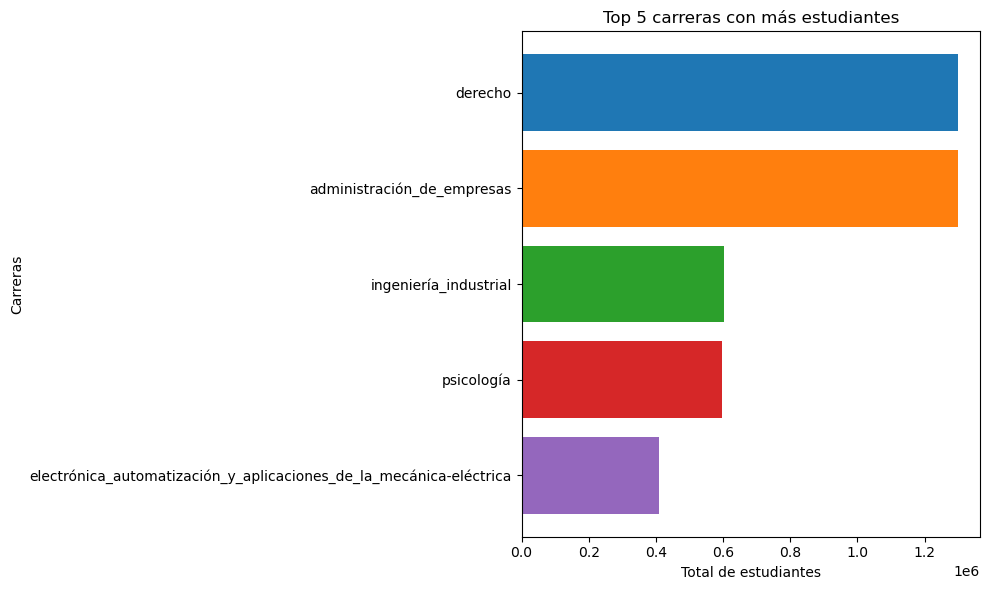

In [46]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='total_students', ascending=False).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['total_students'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Total de estudiantes')
plt.ylabel('Carreras')
plt.title('Top 5 carreras con más estudiantes')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca().invert_yaxis()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()

C:\Users\luisn\AppData\Local\Temp\ipykernel_9128\2730133858.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



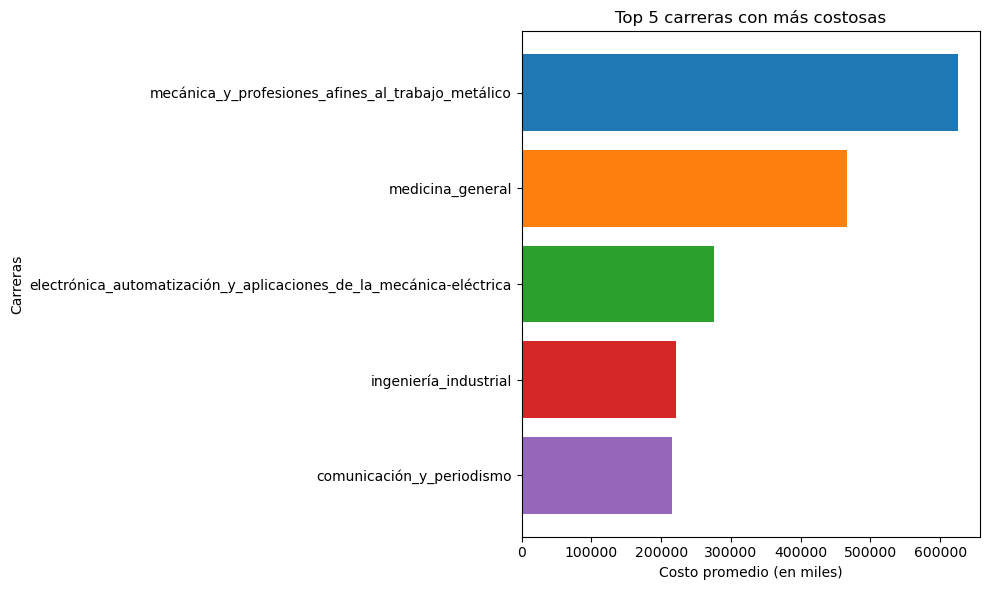

In [93]:
import matplotlib.pyplot as plt
df_unique['avg_cost'] = (df_unique['private_cost'] + df_unique['public_cost']) / 2
# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='avg_cost', ascending=False).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['avg_cost'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Costo promedio (en miles)')
plt.ylabel('Carreras')
plt.title('Top 5 carreras con más costosas')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca().invert_yaxis()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()

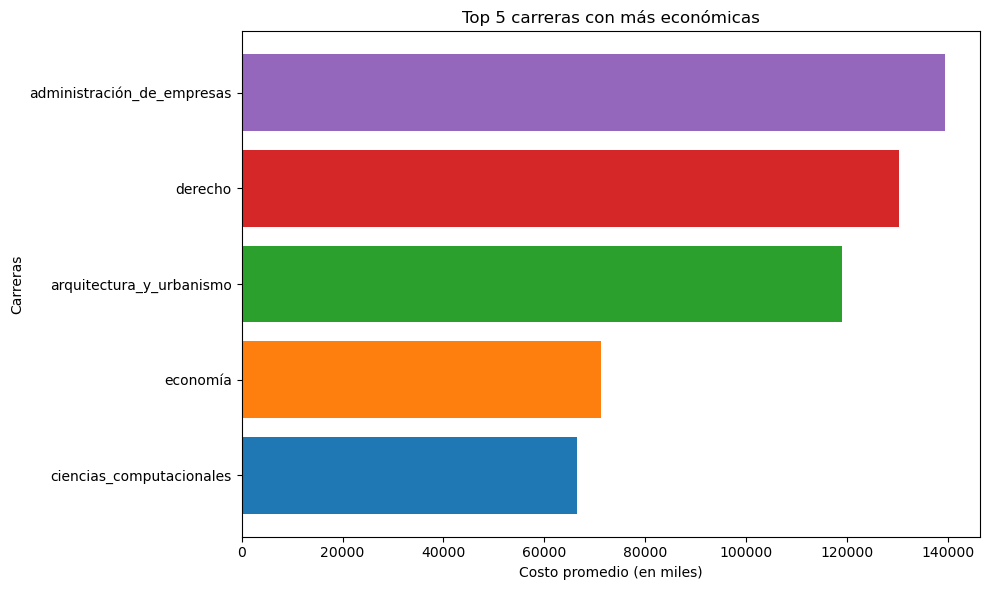

In [94]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='avg_cost', ascending=True).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['avg_cost'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Costo promedio (en miles)')
plt.ylabel('Carreras')
plt.title('Top 5 carreras con más económicas')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()

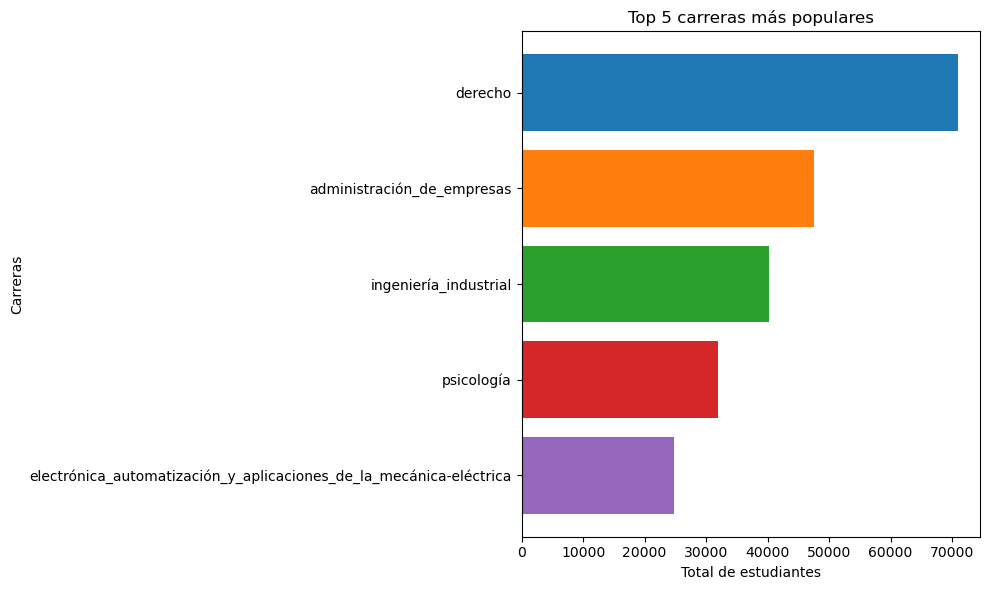

In [56]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='new_graduates_number', ascending=False).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['new_graduates_number'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Total de estudiantes')
plt.ylabel('Carreras')
plt.title('Top 5 carreras más populares')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca().invert_yaxis()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()

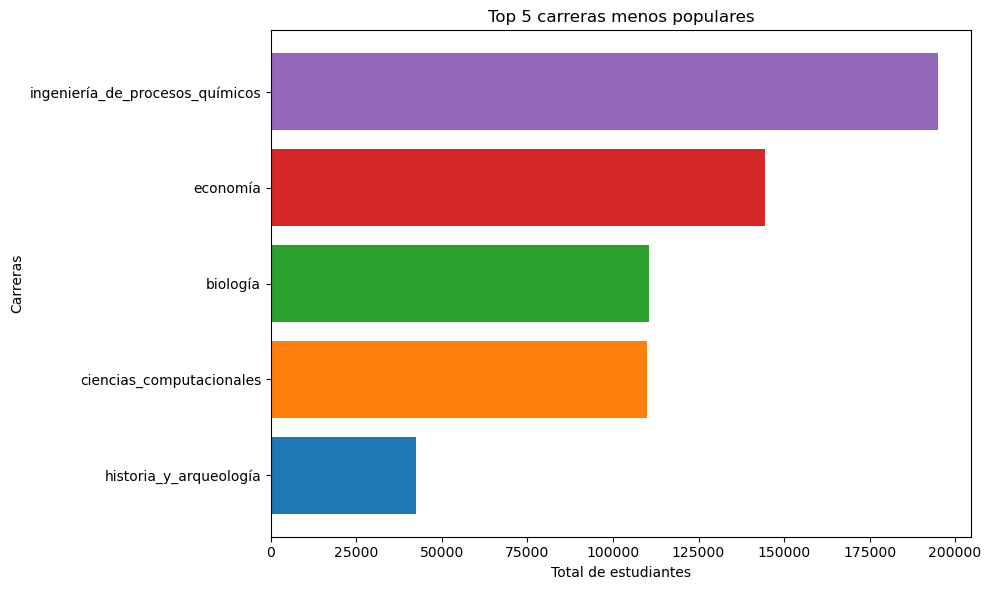

In [97]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='total_students', ascending=True).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['total_students'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Total de estudiantes')
plt.ylabel('Carreras')
plt.title('Top 5 carreras menos populares')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()

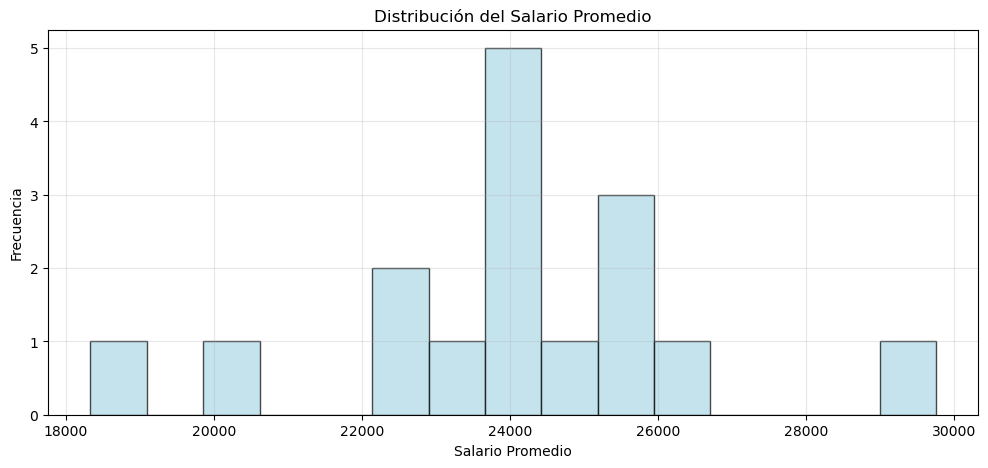

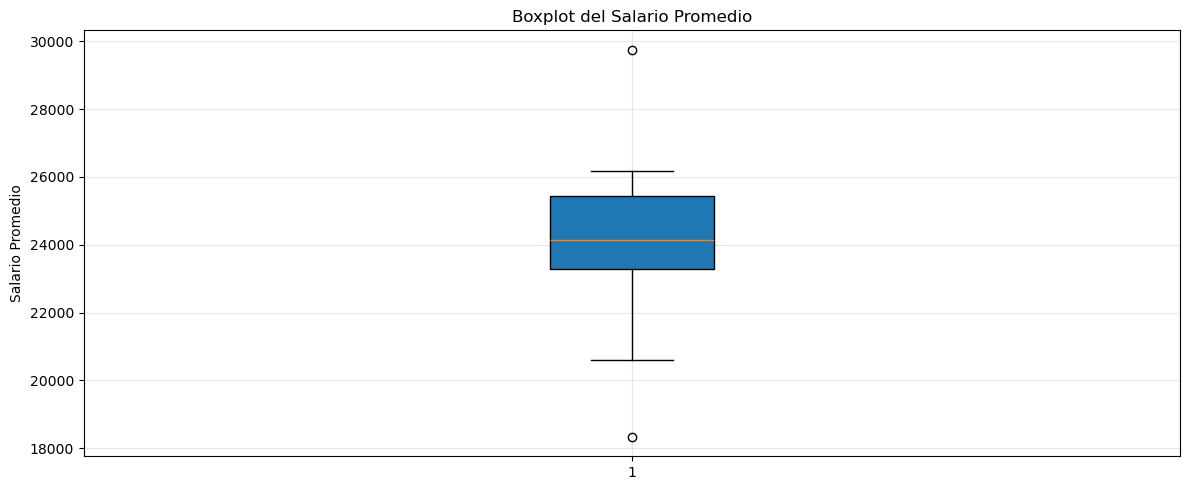

Estadísticas del Salario Promedio:
Media: 24087.72
Mediana: 24131.62
Desviación estándar: 2523.58


In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Gráfica de distribución del salario promedio
plt.figure(figsize=(12, 5))

# Histograma
plt.hist(df_unique['average_salary'], bins=15, color='lightblue', edgecolor='black', alpha=0.7)
plt.xlabel('Salario Promedio')
plt.ylabel('Frecuencia')
plt.title('Distribución del Salario Promedio')
plt.grid(True, alpha=0.3)
plt.show()
# Boxplot
plt.figure(figsize=(12, 5))
plt.boxplot(df_unique['average_salary'], vert=True, patch_artist=True)
plt.ylabel('Salario Promedio')
plt.title('Boxplot del Salario Promedio')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("Estadísticas del Salario Promedio:")
print(f"Media: {df_unique['average_salary'].mean():.2f}")
print(f"Mediana: {df_unique['average_salary'].median():.2f}")
print(f"Desviación estándar: {df_unique['average_salary'].std():.2f}")

C:\Users\luisn\AppData\Local\Temp\ipykernel_9128\2997987315.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['salary_gap'] = df_unique['men_salary'] - df_unique['women_salary']
C:\Users\luisn\AppData\Local\Temp\ipykernel_9128\2997987315.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['gap_percentage'] = (df_unique['salary_gap'] / df_unique['women_salary']) * 100


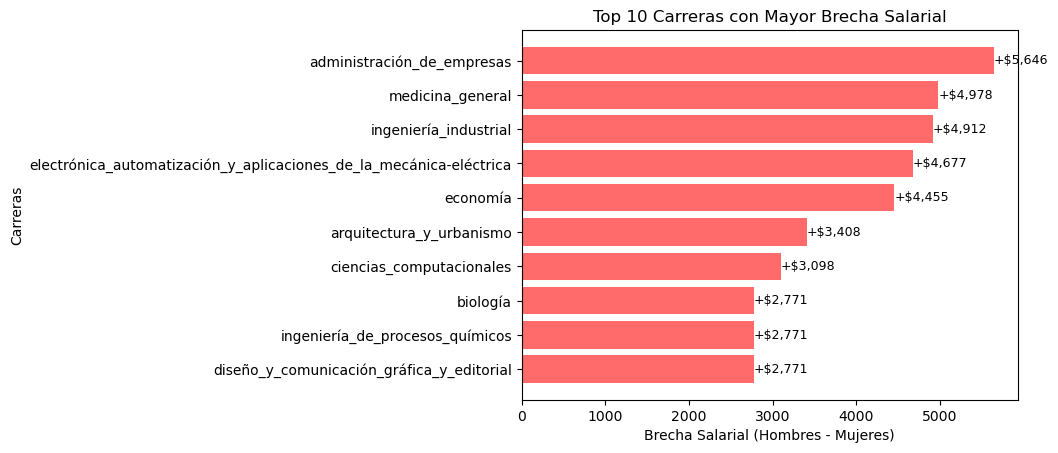

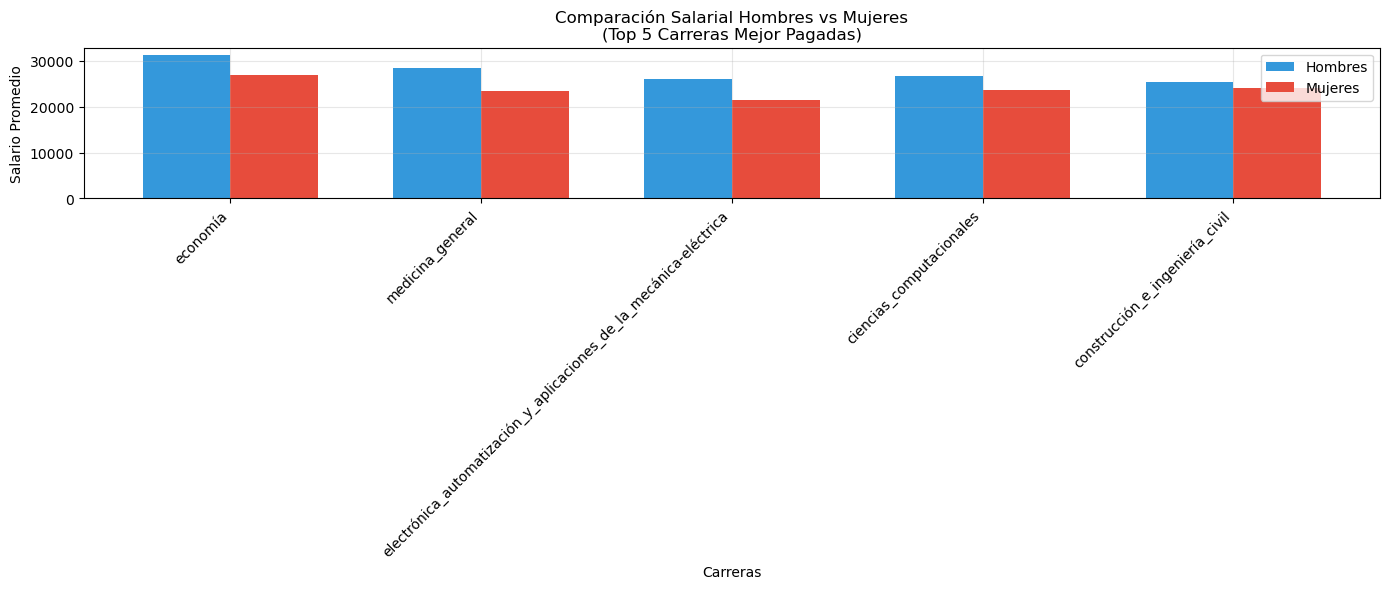


Estadísticas de Brecha Salarial:
Brecha salarial promedio: $2732.08
Brecha porcentual promedio: 12.94%
Carreras con brecha a favor de hombres: 15
Carreras con brecha a favor de mujeres: 1


In [64]:
# Gráfica de brecha salarial
# Subgráfica 1: Comparación directa

# Calcular brecha salarial
df_unique['salary_gap'] = df_unique['men_salary'] - df_unique['women_salary']
df_unique['gap_percentage'] = (df_unique['salary_gap'] / df_unique['women_salary']) * 100

# Top 10 carreras con mayor brecha salarial
df_gap_top10 = df_unique.nlargest(10, 'salary_gap')

bars = plt.barh(df_gap_top10['career'], df_gap_top10['salary_gap'], 
                color=['#ff6b6b' if x > 0 else '#4ecdc4' for x in df_gap_top10['salary_gap']])
plt.xlabel('Brecha Salarial (Hombres - Mujeres)')
plt.ylabel('Carreras')
plt.title('Top 10 Carreras con Mayor Brecha Salarial')
plt.gca().invert_yaxis()

# Agregar valores
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'+${int(width):,}', 
             ha='left' if width > 0 else 'right', 
             va='center', fontsize=9)
plt.show()
# Subgráfica 2: Comparación hombres vs mujeres
plt.figure(figsize=(14, 6))
# Top 5 carreras para comparación
df_comparison = df_unique.nlargest(5, 'average_salary')

x = np.arange(len(df_comparison))
width = 0.35

plt.bar(x - width/2, df_comparison['men_salary'], width, label='Hombres', color='#3498db')
plt.bar(x + width/2, df_comparison['women_salary'], width, label='Mujeres', color='#e74c3c')

plt.xlabel('Carreras')
plt.ylabel('Salario Promedio')
plt.title('Comparación Salarial Hombres vs Mujeres\n(Top 5 Carreras Mejor Pagadas)')
plt.xticks(x, df_comparison['career'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de brecha salarial
print("\nEstadísticas de Brecha Salarial:")
print(f"Brecha salarial promedio: ${df_unique['salary_gap'].mean():.2f}")
print(f"Brecha porcentual promedio: {df_unique['gap_percentage'].mean():.2f}%")
print(f"Carreras con brecha a favor de hombres: {(df_unique['salary_gap'] > 0).sum()}")
print(f"Carreras con brecha a favor de mujeres: {(df_unique['salary_gap'] < 0).sum()}")

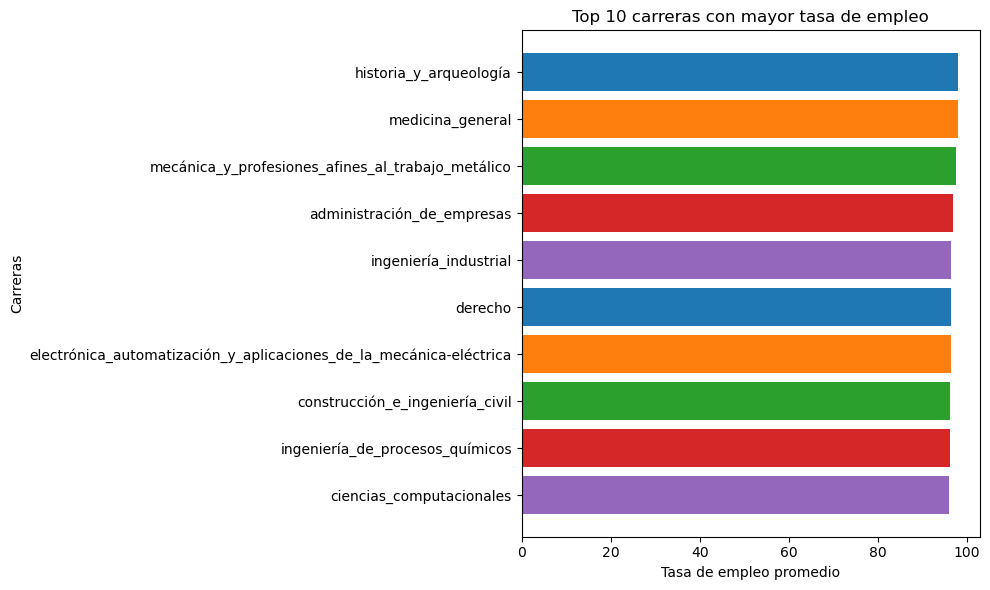

In [71]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='occupation_rate', ascending=False).head(10)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['occupation_rate'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Tasa de empleo promedio')
plt.ylabel('Carreras')
plt.title('Top 10 carreras con mayor tasa de empleo')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca().invert_yaxis()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()

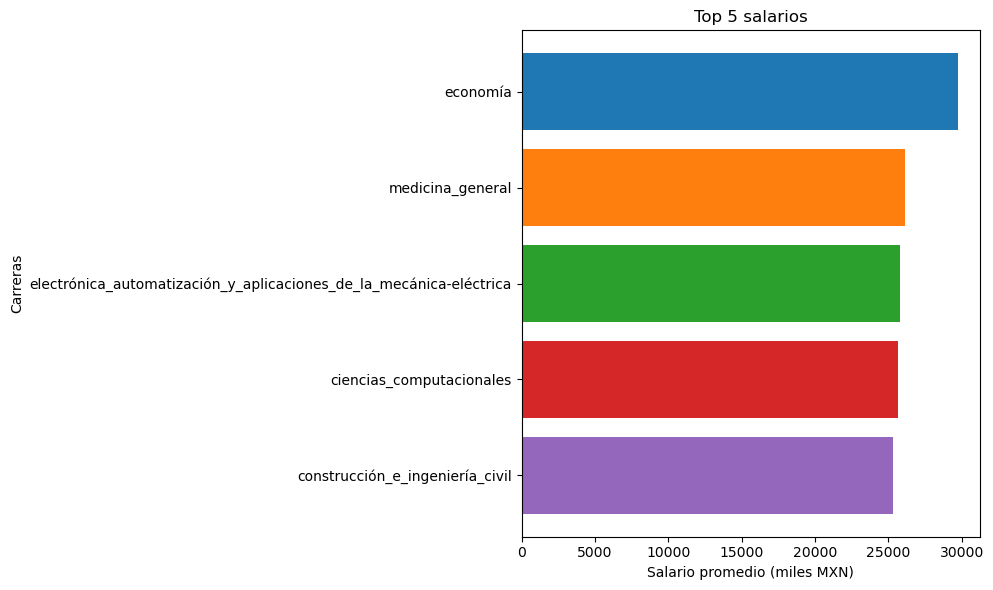

In [74]:
import matplotlib.pyplot as plt

# Ordenar de mayor a menor y tomar el top 5
df_top5 = df_unique.sort_values(by='average_salary', ascending=False).head(5)

# Crear la gráfica horizontal con colores
plt.figure(figsize=(10, 6))
bars = plt.barh(df_top5['career'], df_top5['average_salary'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Configurar etiquetas y título
plt.xlabel('Salario promedio (miles MXN)')
plt.ylabel('Carreras')
plt.title('Top 5 salarios')

# Invertir el eje Y para mostrar el mayor en la parte superior
plt.gca().invert_yaxis()

# Agregar valores en las barras

# Ajustar el layout
plt.tight_layout()

# Mostrar la gráfica
plt.show()

In [77]:
df_unique

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,men_salary,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase,salary_gap,gap_percentage
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337269,10559,47375.00,248283.00,...,25518.00,21204.00,26826.00,27119.00,18928.00,3.9,41396.00,191.62,1410.00,5.848681
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109896,990,42437.00,90757.00,...,26821.00,17118.00,28654.00,27745.00,17327.00,6.9,43574.00,206.11,3098.00,13.059057
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601331,40232,49736.00,393684.00,...,24854.00,20188.00,25369.00,25109.00,14568.00,3.2,43391.00,214.62,4912.00,24.631431
6,6,3,Ingeniería Eléctrica,1,74.5,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886.00,496800.00,...,26108.00,21596.00,28051.00,27429.00,15484.00,1.9,41086.00,185.06,4677.00,21.823527
8,8,4,Ingeniería Mecánica,1,80.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344.00,1200000.00,...,23165.00,22696.00,24811.00,25981.00,14836.00,1.2,42794.00,206.03,-6072.00,-20.768205
10,10,5,Médico Cirujano,1,78.6,medicina_general,292141,18871,70605.00,860982.00,...,28457.00,21990.00,27437.00,27888.00,17390.00,NaN,40634.92,NaN,4978.00,21.201925
12,12,6,Psicología,1,88.1,psicología,595676,31993,60886.00,269914.00,...,19192.00,16807.00,18994.00,20112.00,12355.00,9.6,28302.00,184.26,1152.00,6.385809
14,14,7,Biología,1,83.6,biología,110499,4180,51513.77,373723.54,...,25186.92,20146.85,25615.23,26128.62,16177.08,14.3,40634.92,NaN,2771.84,12.365961
16,16,8,Ingeniería Química,1,80.5,ingeniería_de_procesos_químicos,194965,9542,51513.77,373723.54,...,25186.92,20146.85,25615.23,26128.62,16177.08,3.8,40634.92,NaN,2771.84,12.365961
18,18,9,Derecho,1,84.2,derecho,1300000,70987,52710.00,208023.00,...,23349.00,17164.00,23697.00,24653.00,15686.00,8.8,40639.00,222.62,2503.00,12.007100


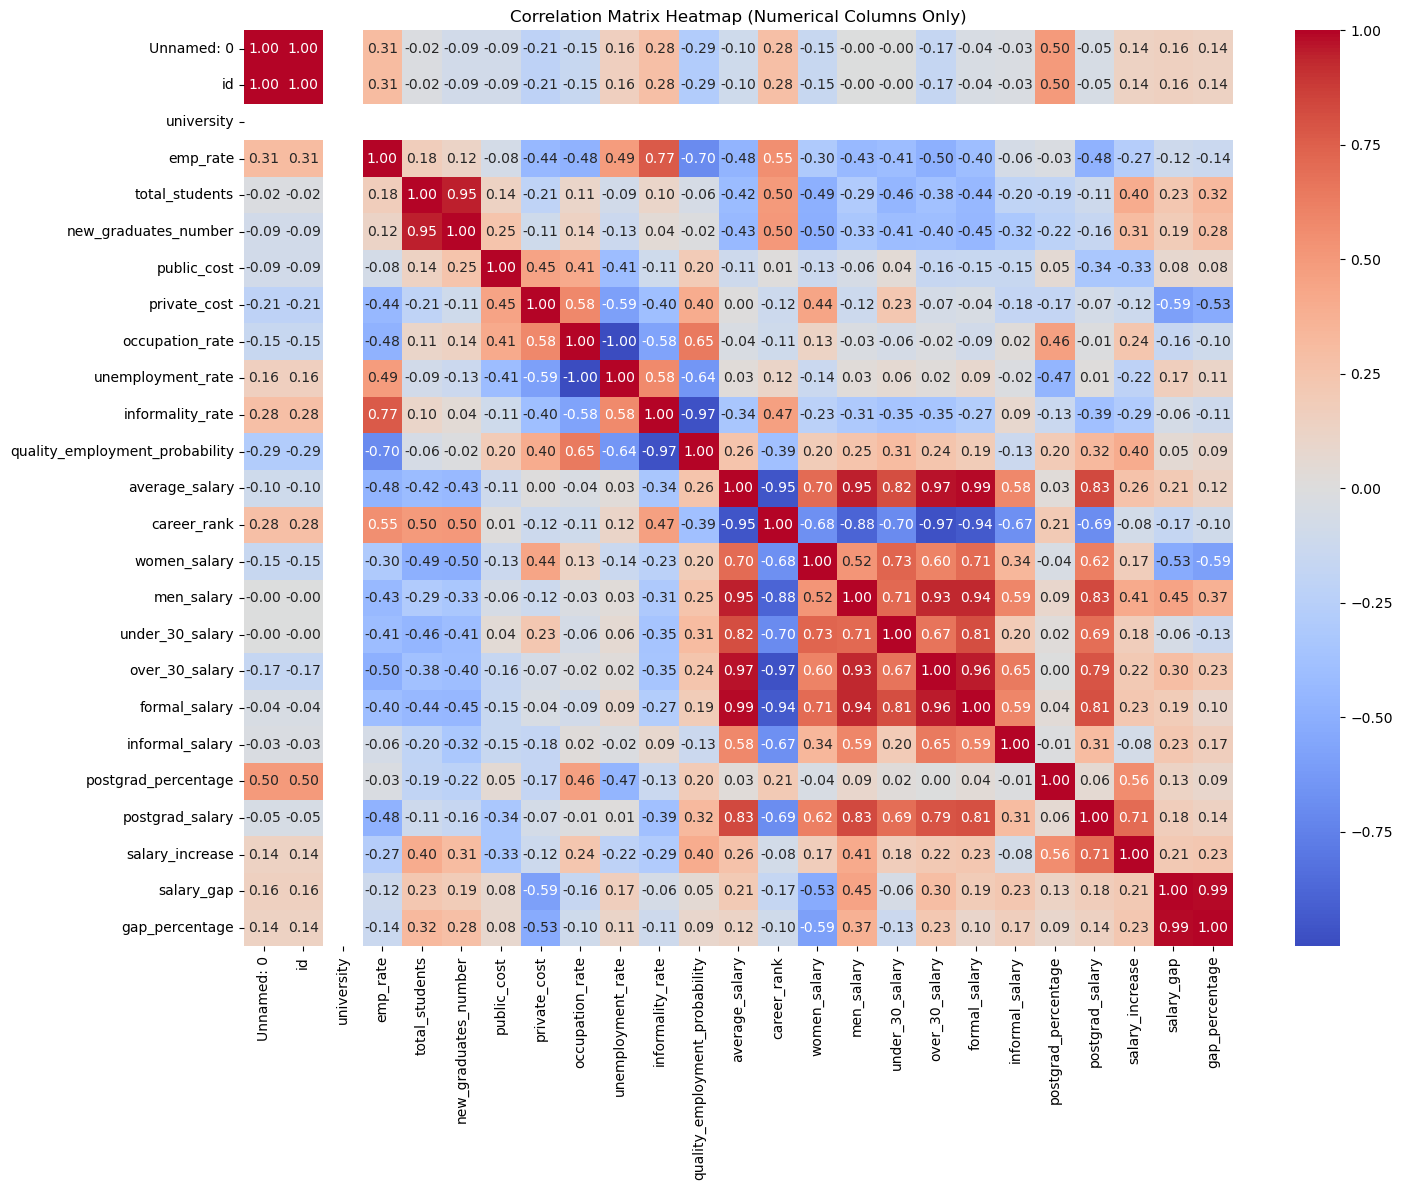

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate correlation matrix only for numerical columns
numerical_df = df_unique.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()

# Create a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap (Numerical Columns Only)')
plt.tight_layout()
plt.show()

In [83]:
df_unique

,Unnamed: 0,id,name,university,emp_rate,career,total_students,new_graduates_number,public_cost,private_cost,...,under_30_salary,over_30_salary,formal_salary,informal_salary,postgrad_percentage,postgrad_salary,salary_increase,salary_gap,gap_percentage,avg_cost
0,0,0,Ingeniería Civil,1,81.7,construcción_e_ingeniería_civil,337269,10559,47375.00,248283.00,...,21204.00,26826.00,27119.00,18928.00,3.9,41396.00,191.62,1410.00,5.848681,147829.000
2,2,1,Ingeniería en Computación,1,83.0,ciencias_computacionales,109896,990,42437.00,90757.00,...,17118.00,28654.00,27745.00,17327.00,6.9,43574.00,206.11,3098.00,13.059057,66597.000
4,4,2,Ingeniería Industrial,1,80.0,ingeniería_industrial,601331,40232,49736.00,393684.00,...,20188.00,25369.00,25109.00,14568.00,3.2,43391.00,214.62,4912.00,24.631431,221710.000
6,6,3,Ingeniería Eléctrica,1,74.5,electrónica_automatización_y_aplicaciones_de_l...,408206,24702,54886.00,496800.00,...,21596.00,28051.00,27429.00,15484.00,1.9,41086.00,185.06,4677.00,21.823527,275843.000
8,8,4,Ingeniería Mecánica,1,80.0,mecánica_y_profesiones_afines_al_trabajo_metálico,205424,11478,51344.00,1200000.00,...,22696.00,24811.00,25981.00,14836.00,1.2,42794.00,206.03,-6072.00,-20.768205,625672.000
10,10,5,Médico Cirujano,1,78.6,medicina_general,292141,18871,70605.00,860982.00,...,21990.00,27437.00,27888.00,17390.00,NaN,40634.92,NaN,4978.00,21.201925,465793.500
12,12,6,Psicología,1,88.1,psicología,595676,31993,60886.00,269914.00,...,16807.00,18994.00,20112.00,12355.00,9.6,28302.00,184.26,1152.00,6.385809,165400.000
14,14,7,Biología,1,83.6,biología,110499,4180,51513.77,373723.54,...,20146.85,25615.23,26128.62,16177.08,14.3,40634.92,NaN,2771.84,12.365961,212618.655
16,16,8,Ingeniería Química,1,80.5,ingeniería_de_procesos_químicos,194965,9542,51513.77,373723.54,...,20146.85,25615.23,26128.62,16177.08,3.8,40634.92,NaN,2771.84,12.365961,212618.655
18,18,9,Derecho,1,84.2,derecho,1300000,70987,52710.00,208023.00,...,17164.00,23697.00,24653.00,15686.00,8.8,40639.00,222.62,2503.00,12.007100,130366.500


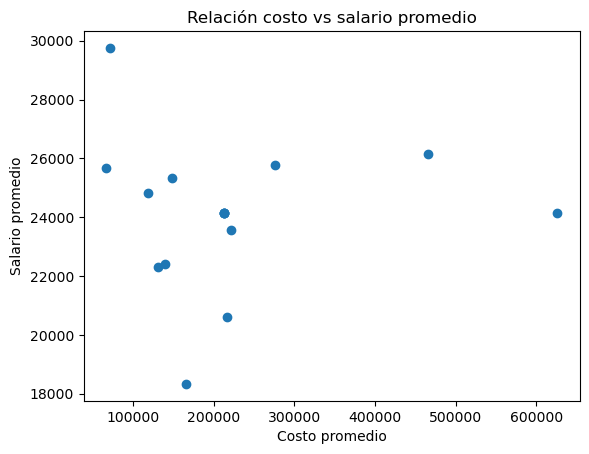

In [85]:
plt.scatter(df_unique['avg_cost'], df_unique['average_salary'])

# Add labels and title for clarity
plt.xlabel("Costo promedio")
plt.ylabel("Salario promedio")
plt.title("Relación costo vs salario promedio")

# Display the plot
plt.show()

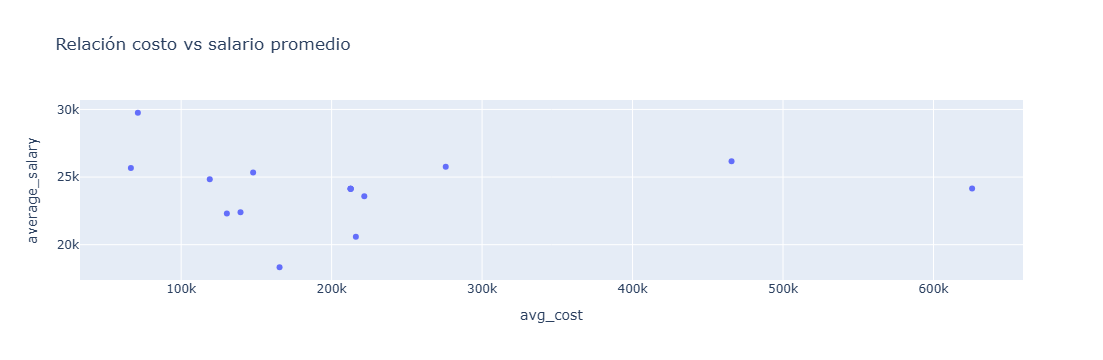

In [91]:
import plotly.express as px

fig = px.scatter(df_unique, 
                 x='avg_cost', 
                 y='average_salary', 
                 hover_data=['career'],  # muestra la carrera al hacer hover
                 title="Relación costo vs salario promedio")
fig.show()

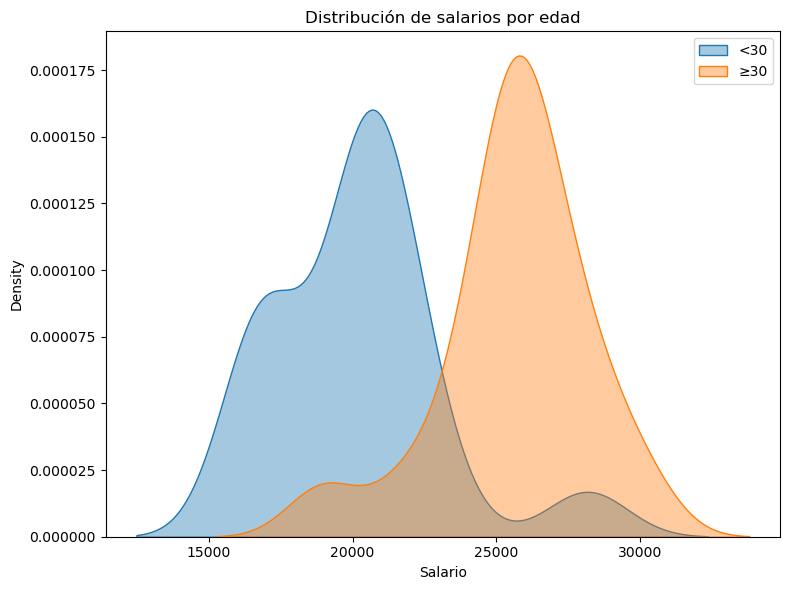

In [100]:
plt.figure(figsize=(8,6))
sns.kdeplot(df['under_30_salary'].dropna(), label='<30', fill=True, alpha=0.4)
sns.kdeplot(df['over_30_salary'].dropna(), label='≥30', fill=True, alpha=0.4)
plt.title("Distribución de salarios por edad"); 
plt.xlabel("Salario"); 
plt.legend(); 
plt.tight_layout(); 
plt.show()

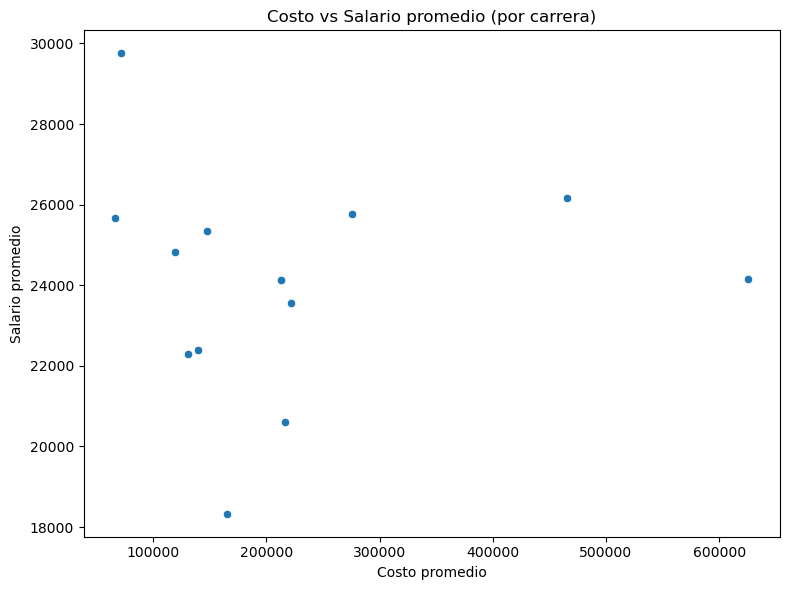

In [106]:
agg = df_unique.groupby('career')[['avg_cost', 'average_salary']].mean().dropna()
plt.figure(figsize=(8,6))
sns.scatterplot(data=agg, x='avg_cost', y='average_salary')
plt.title("Costo vs Salario promedio (por carrera)"); plt.xlabel("Costo promedio"); plt.ylabel("Salario promedio")
plt.tight_layout(); plt.show()

In [107]:
df_unique.columns

Index(['Unnamed: 0', 'id', 'name', 'university', 'emp_rate', 'career',
       'total_students', 'new_graduates_number', 'public_cost', 'private_cost',
       'public_quality_rating', 'private_quality_rating', 'occupation_rate',
       'unemployment_rate', 'informality_rate',
       'quality_employment_probability', 'average_salary', 'career_rank',
       'women_salary', 'men_salary', 'under_30_salary', 'over_30_salary',
       'formal_salary', 'informal_salary', 'postgrad_percentage',
       'postgrad_salary', 'salary_increase', 'salary_gap', 'gap_percentage',
       'avg_cost'],
      dtype='object')

In [ ]:
text = " ".join(df['career'].dropna().astype(str).tolist())
text = unidecode(text.lower())
wc = WordCloud(width=1000, height=400, background_color="white").generate(text)
plt.figure(figsize=(12,5)); plt.imshow(wc); plt.axis("off"); plt.title("Nube de palabras - Carreras"); plt.show()